<a href="https://colab.research.google.com/github/Akash14-09/CP_Coach/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Phase 1 --> Data Collection

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
handle = "akashdwivedi1409"

url = f"https://codeforces.com/api/user.info?handles={handle}"

response = requests.get(url)

data = response.json()

data

{'status': 'OK',
 'result': [{'lastName': 'Dwivedi',
   'country': 'India',
   'lastOnlineTimeSeconds': 1779934646,
   'city': 'Pratāpgarh',
   'rating': 570,
   'friendOfCount': 31,
   'titlePhoto': 'https://userpic.codeforces.org/4917734/title/d299031c37d157f7.jpg',
   'handle': 'akashdwivedi1409',
   'avatar': 'https://userpic.codeforces.org/4917734/avatar/71bed56776fe2b9e.jpg',
   'firstName': 'Akash',
   'contribution': 0,
   'organization': 'BIET, Jhansi',
   'rank': 'newbie',
   'maxRating': 941,
   'registrationTimeSeconds': 1750341472,
   'maxRank': 'newbie'}]}

In [3]:
user = data['result'][0]

user_info = {
    "handle": user.get("handle"),
    "rating": user.get("rating"),
    "maxRating": user.get("maxRating"),
    "rank": user.get("rank"),
    "maxRank": user.get("maxRank"),
    "contribution": user.get("contribution"),
    "friendOfCount": user.get("friendOfCount")
}

user_info

{'handle': 'akashdwivedi1409',
 'rating': 570,
 'maxRating': 941,
 'rank': 'newbie',
 'maxRank': 'newbie',
 'contribution': 0,
 'friendOfCount': 31}

In [4]:
url = f"https://codeforces.com/api/user.status?handle={handle}"

response = requests.get(url)

data = response.json()

submissions = data['result']

len(submissions)

838

In [5]:
rows = []

for sub in submissions:

    rows.append({
        "submission_id": sub.get("id"),
        "problem_name": sub["problem"].get("name"),
        "rating": sub["problem"].get("rating"),
        "tags": sub["problem"].get("tags"),
        "verdict": sub.get("verdict"),
        "language": sub.get("programmingLanguage"),
        "creation_time": sub.get("creationTimeSeconds")
    })

df = pd.DataFrame(rows)

df.head()

,submission_id,problem_name,rating,tags,verdict,language,creation_time
0,376358373,Consecutive Subsequence,1700.0,[dp],OK,"C++23 (GCC 14-64, msys2)",1779941701
1,376352943,Flowers,1700.0,[dp],OK,"C++23 (GCC 14-64, msys2)",1779936363
2,376325273,Yet Another Broken Keyboard,1200.0,"[combinatorics, dp, implementation]",OK,"C++23 (GCC 14-64, msys2)",1779900360
3,376167553,Number of Ways,1700.0,"[binary search, brute force, data structures, ...",OK,"C++23 (GCC 14-64, msys2)",1779787744
4,376166882,Number of Ways,1700.0,"[binary search, brute force, data structures, ...",WRONG_ANSWER,"C++23 (GCC 14-64, msys2)",1779787303


In [6]:
df['rating'].mean()
#avg of all the problems that i solved till now

np.float64(1082.4050632911392)

In [7]:
df["verdict"].value_counts()

,count
verdict,
OK,462
WRONG_ANSWER,295
TIME_LIMIT_EXCEEDED,38
COMPILATION_ERROR,33
RUNTIME_ERROR,5
MEMORY_LIMIT_EXCEEDED,3
SKIPPED,1
IDLENESS_LIMIT_EXCEEDED,1


In [8]:
df["language"].value_counts().head(10)

,count
language,
C++20 (GCC 13-64),540
"C++23 (GCC 14-64, msys2)",288
GNU C11,8
C++17 (GCC 7-32),1
PyPy 3-64,1


In [9]:
all_tags = []

for tags in df["tags"]:

    if isinstance(tags, list):
        all_tags.extend(tags)

tag_counts = Counter(all_tags)

tag_counts.most_common(10)

[('math', 368),
 ('greedy', 357),
 ('implementation', 261),
 ('brute force', 174),
 ('dp', 160),
 ('sortings', 118),
 ('constructive algorithms', 116),
 ('number theory', 87),
 ('binary search', 76),
 ('data structures', 67)]

In [12]:
#converting the scientific time to readable creation time

In [13]:
df["creation_time"] = pd.to_datetime(
    df["creation_time"],
    unit="s"
)

df.head()

,submission_id,problem_name,rating,tags,verdict,language,creation_time
0,376358373,Consecutive Subsequence,1700.0,[dp],OK,"C++23 (GCC 14-64, msys2)",2026-05-28 04:15:01
1,376352943,Flowers,1700.0,[dp],OK,"C++23 (GCC 14-64, msys2)",2026-05-28 02:46:03
2,376325273,Yet Another Broken Keyboard,1200.0,"[combinatorics, dp, implementation]",OK,"C++23 (GCC 14-64, msys2)",2026-05-27 16:46:00
3,376167553,Number of Ways,1700.0,"[binary search, brute force, data structures, ...",OK,"C++23 (GCC 14-64, msys2)",2026-05-26 09:29:04
4,376166882,Number of Ways,1700.0,"[binary search, brute force, data structures, ...",WRONG_ANSWER,"C++23 (GCC 14-64, msys2)",2026-05-26 09:21:43


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 838 entries, 0 to 837
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   submission_id  838 non-null    int64         
 1   problem_name   838 non-null    object        
 2   rating         790 non-null    float64       
 3   tags           838 non-null    object        
 4   verdict        838 non-null    object        
 5   language       838 non-null    object        
 6   creation_time  838 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 46.0+ KB


In [15]:
df["year"] = df["creation_time"].dt.year
df["month"] = df["creation_time"].dt.month
df["day"] = df["creation_time"].dt.day

In [16]:
df.to_csv("akashdwivedi1409_submissions_updated.csv", index=False)

In [17]:
# from google.colab import files

# files.download("akashdwivedi1409_submissions_updated.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Phase 2 --> Feature Engineering

###Solve Rate
How many solutions are getting accepted

In [18]:
total_submissions = len(df)

accepted = len(df[df["verdict"] == "OK"])

solve_rate = (accepted / total_submissions) * 100

print("Solve Rate:", round(solve_rate, 2), "%")

Solve Rate: 55.13 %


In [20]:
#avg solved rating
solved_df = df[df["verdict"] == "OK"]
solved_df["rating"].mean()

np.float64(1087.3873873873874)

In [21]:
#Hardest solved problem

In [22]:
solved_df["rating"].max()

2000.0

Strength Detection --> Gives you the no of accepted solutions on each topic

In [23]:
tag_success = {}

for _, row in solved_df.iterrows():

    tags = row["tags"]

    if isinstance(tags, list):

        for tag in tags:

            if tag not in tag_success:
                tag_success[tag] = 0

            tag_success[tag] += 1

sorted(
    tag_success.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

[('math', 191),
 ('greedy', 189),
 ('implementation', 137),
 ('dp', 101),
 ('brute force', 100),
 ('sortings', 66),
 ('constructive algorithms', 59),
 ('binary search', 48),
 ('strings', 45),
 ('number theory', 44)]

weakness detection --> gives you all the failed submissions for each topic

In [24]:
failed_df = df[df["verdict"] != "OK"]

tag_failures = {}

for _, row in failed_df.iterrows():

    tags = row["tags"]

    if isinstance(tags, list):

        for tag in tags:

            if tag not in tag_failures:
                tag_failures[tag] = 0

            tag_failures[tag] += 1

sorted(
    tag_failures.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

[('math', 177),
 ('greedy', 168),
 ('implementation', 124),
 ('brute force', 74),
 ('dp', 59),
 ('constructive algorithms', 57),
 ('sortings', 52),
 ('number theory', 43),
 ('binary search', 28),
 ('data structures', 27)]

Rating Distribution Plot

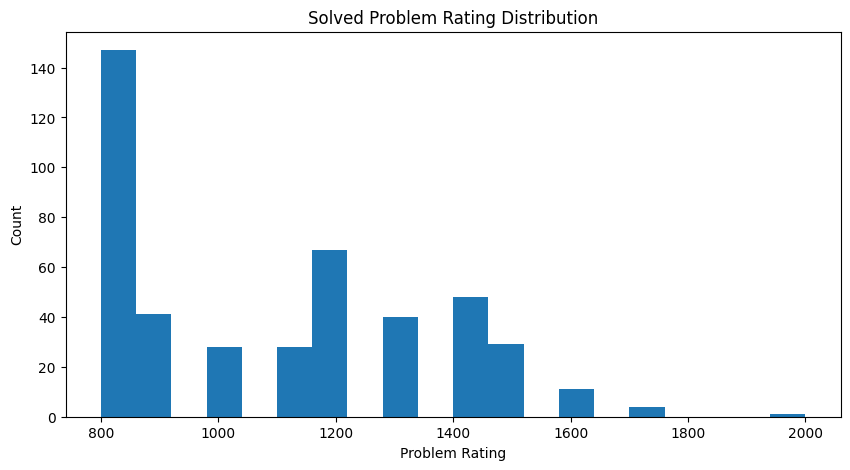

In [25]:
solved_df["rating"].plot(
    kind="hist",
    bins=20,
    figsize=(10,5)
)

plt.xlabel("Problem Rating")
plt.ylabel("Count")
plt.title("Solved Problem Rating Distribution")

plt.show()

Daily Activity Analysis

In [28]:
daily_activity = (
    solved_df
    .groupby(
        solved_df["creation_time"].dt.date
    )
    .size()
)

daily_activity.head()

,0
creation_time,
2025-07-24,2
2025-07-27,1
2025-07-28,1
2025-07-30,1
2025-08-02,1


Plotting Consistency

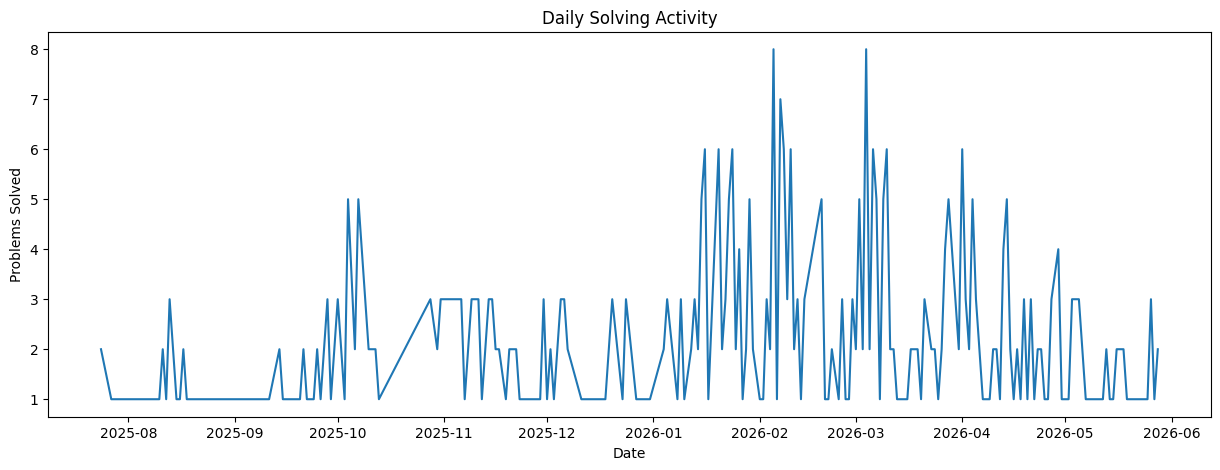

In [29]:
daily_activity.plot(
    figsize=(15,5)
)

plt.xlabel("Date")
plt.ylabel("Problems Solved")
plt.title("Daily Solving Activity")

plt.show()